# **Install Packages**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlalchemy as sa

Pandas, NumPy, Matplotlib, and Seaborn are packages for exploratory data analysis, while SQLAlchemy is for importing data from SQL databases.

In [2]:
from sqlalchemy import create_engine
import urllib.parse
from getpass import getpass

from matplotlib.ticker import FuncFormatter

## **Setup MySQL**

This section is used to securely configure MySQL database connection credentials and then create an *engine* object using SQLAlchemy.

`getpass()`: Secures password input so that it does not appear in plain text on the screen as it is typed.

In [3]:
# Credentials
user = 'root'
password = getpass('Enter your database password: ')
host = 'localhost'
db = 'bike_store'

`urllib.parse.quote_plus()`: Converts special characters in passwords (such as @ or #) into URL-safe format to prevent them from corrupting the connection string.

In [4]:
safe_password = urllib.parse.quote_plus(password)
engine = create_engine(f'mysql+pymysql://{user}:{safe_password}@{host}/{db}')

This section is used to verify that a connection to the MySQL database has been established successfully and to ensure that data can be retrieved using Pandas.

1. `try ... except`: Used for error handling (exception handling). If an error occurs, the program will not crash but will instead display the error message "Connection failed ..."

2. `pd.read_sql()`: Executes an SQL query through the established connection.

3. `display()`: Displays the first 5 rows of the executed query.

In [5]:
# Test connection
try:
    df_sales = pd.read_sql("SELECT * FROM v_sales_analysis LIMIT 5", engine)
    print("Koneksi Sukses! Data berhasil ditarik.")
    display(df_sales)
except Exception as e:
    print(f"Gagal koneksi: {e}")

Koneksi Sukses! Data berhasil ditarik.


,order_id,order_date,store_name,customer_id,customer_name,product_name,category_name,brand_name,quantity,list_price,discount,total_revenue
0,1476,2018-03-31,Baldwin Bikes,35,Guillermina Noble,Electra Loft Go! 8i - 2018,Electric Bikes,Electra,1,2799.99,0.10,2519.9910
1,1585,2018-04-26,Santa Cruz Bikes,157,Carola Rodriquez,Electra Loft Go! 8i - 2018,Electric Bikes,Electra,1,2799.99,0.10,2519.9910
2,1611,2018-09-06,Baldwin Bikes,6,Lyndsey Bean,Electra Loft Go! 8i - 2018,Electric Bikes,Electra,1,2799.99,0.07,2603.9907
3,1356,2018-01-19,Baldwin Bikes,1161,Santa Larson,Electra Townie Go! 8i - 2017/2018,Electric Bikes,Electra,1,2599.99,0.05,2469.9905
4,1434,2018-03-14,Baldwin Bikes,595,Frederica Rojas,Electra Townie Commute Go! - 2018,Electric Bikes,Electra,1,2999.99,0.10,2699.9910


Based on the connection test, the results show that the connection between MySQL and Python was successful.

# **Import Data**

After connecting to MySQL, the next step is to import the queries (views) created in MySQL as the `df_...` database via the "engine." The three queries being imported are those related to **sales analysis**, **inventory status**, and **staff performance**.

In [6]:
# sales analysis
df_sales = pd.read_sql("SELECT * FROM v_sales_analysis", engine)
df_sales.head()

,order_id,order_date,store_name,customer_id,customer_name,product_name,category_name,brand_name,quantity,list_price,discount,total_revenue
0,1476,2018-03-31,Baldwin Bikes,35,Guillermina Noble,Electra Loft Go! 8i - 2018,Electric Bikes,Electra,1,2799.99,0.10,2519.9910
1,1585,2018-04-26,Santa Cruz Bikes,157,Carola Rodriquez,Electra Loft Go! 8i - 2018,Electric Bikes,Electra,1,2799.99,0.10,2519.9910
2,1611,2018-09-06,Baldwin Bikes,6,Lyndsey Bean,Electra Loft Go! 8i - 2018,Electric Bikes,Electra,1,2799.99,0.07,2603.9907
3,1356,2018-01-19,Baldwin Bikes,1161,Santa Larson,Electra Townie Go! 8i - 2017/2018,Electric Bikes,Electra,1,2599.99,0.05,2469.9905
4,1434,2018-03-14,Baldwin Bikes,595,Frederica Rojas,Electra Townie Commute Go! - 2018,Electric Bikes,Electra,1,2999.99,0.10,2699.9910


In [7]:
# inventory analysis
df_inventory = pd.read_sql("SELECT * FROM v_inventory_status", engine)
df_inventory.head()

,store_name,product_name,category_name,brand_name,stock_level
0,Santa Cruz Bikes,Trek Superfly 24 - 2017/2018,Children Bicycles,Trek,23
1,Santa Cruz Bikes,Trek Precaliber 24 7-speed Girl's - 2018,Children Bicycles,Trek,17
2,Santa Cruz Bikes,Trek Precaliber 24 21-speed Girl's - 2018,Children Bicycles,Trek,17
3,Santa Cruz Bikes,Trek Precaliber 24 21-speed Boy's - 2018,Children Bicycles,Trek,13
4,Santa Cruz Bikes,Trek Precaliber 24 (7-Speed) - Boys - 2018,Children Bicycles,Trek,7


In [8]:
# staff performance analysis
df_staff_performance = pd.read_sql("SELECT * FROM v_staff_performance", engine)
df_staff_performance

,staff_id,staff_name,store_name,manager_id,total_orders_handled
0,1,Fabiola Jackson,Santa Cruz Bikes,NaN,0
1,2,Mireya Copeland,Santa Cruz Bikes,1.0,164
2,3,Genna Serrano,Santa Cruz Bikes,2.0,184
3,4,Virgie Wiggins,Santa Cruz Bikes,2.0,0
4,5,Jannette David,Baldwin Bikes,1.0,0
5,6,Marcelene Boyer,Baldwin Bikes,5.0,553
6,7,Venita Daniel,Baldwin Bikes,5.0,540
7,8,Kali Vargas,Rowlett Bikes,1.0,88
8,9,Layla Terrell,Rowlett Bikes,7.0,86
9,10,Bernardine Houston,Rowlett Bikes,7.0,0


# **Sales Analysis**

After importing the data, the next step is to focus on exploratory data analysis (EDA). To begin, the first query performed is a sales analysis. In this section, the purpose of the EDA is to analyze sales volume (as quantity) and revenue by examining the following aspects: 

1. Monthly trends 

2. Revenue and Demand by category, brand, and product 

3. Top customers

4. Store performance

## **Revenue Trend**

The first step in EDA sales analysis is to analyze monthly trends in sales volume and revenue. The results of the analysis are visualized using a dual-line chart.

In [ ]:
# Revenue Trend Analysis
df_sales['pesanan_date'] = pd.to_datetime(df_sales['order_date'])

# Monthly quantity and revenue
monthly_sales = df_sales.groupby(df_sales['order_date'].dt.to_period('M')).agg({'quantity': 'sum', 'total_revenue': 'sum'})
monthly_sales.index = monthly_sales.index.to_timestamp()

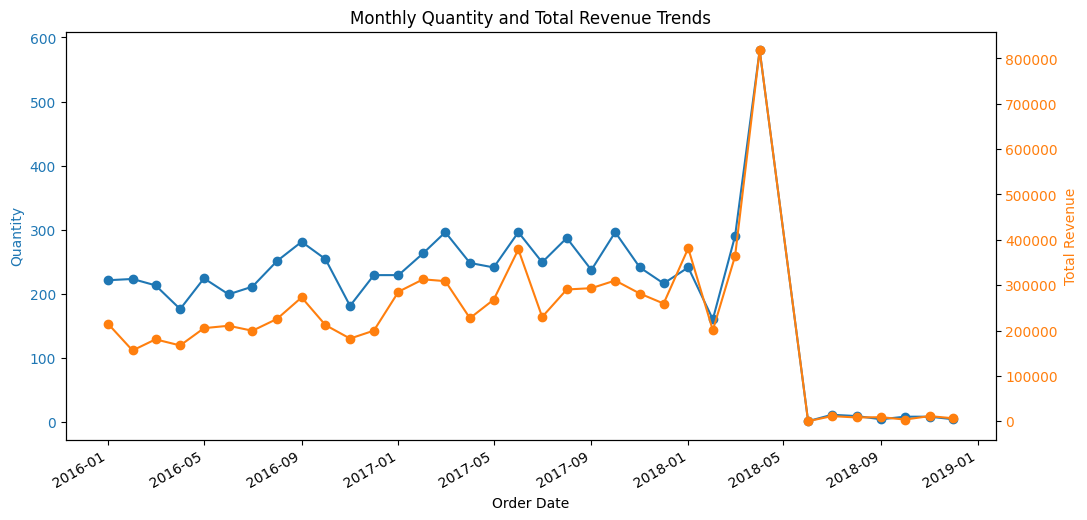

In [10]:
# Plot quantity and revenue trends
fig, ax1 = plt.subplots(figsize=(12, 6))
color = 'tab:blue'
ax1.set_xlabel('Order Date')
ax1.set_ylabel('Quantity', color=color)
ax1.plot(monthly_sales.index, monthly_sales['quantity'], color=color, marker='o')
ax1.tick_params(axis='y', labelcolor=color)
ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Total Revenue', color=color)
ax2.plot(monthly_sales.index, monthly_sales['total_revenue'], color=color, marker='o')
ax2.tick_params(axis='y', labelcolor=color)
fig.autofmt_xdate()
plt.title('Monthly Quantity and Total Revenue Trends')
plt.show()

Based on the monthly trends in sales volume and revenue, we can conclude:
1. The trends in sales volume and revenue are aligned, whether they are rising, falling, or fluctuating;
2. The trends were fluctuating until around February 2018, then surged sharply in April 2018;
3. After April 2018, sales volume and total revenue experienced a drastic decline, reaching a low point (nearing zero), and this trend remained stagnant until early 2019.

Turning to the raw data, we can see that this extreme decline was identified as a data anomaly, supported by the following indications: 
1. Limited transaction records, as between May 2018 and January 2019, only a dozen transactions were recorded per month; 
2. Obstacles or interruptions in the data consolidation process within the system database during that period, indicating that the historical data after April 2018 does not reflect actual conditions on the ground.





## **Category Analysis**

In this section, we examine sales demand for the marketed product categories and their impact on revenue. The results of the analysis are visualized using a dual bar-line chart. 

In [11]:
pd.options.display.float_format = '{:,.2f}'.format

In [12]:
# Categor_df with quantity and revenue
category_sales = df_sales.groupby('category_name').agg({'quantity': 'sum', 'total_revenue': 'sum'}).reset_index()
category_sales.sort_values('total_revenue', ascending=False, inplace=True)

category_sales

,category_name,quantity,total_revenue
5,Mountain Bikes,1755,"2,715,079.53"
6,Road Bikes,559,"1,665,098.49"
2,Cruisers Bicycles,2063,"995,032.62"
4,Electric Bikes,315,"916,684.78"
3,Cyclocross Bicycles,394,"711,011.84"
1,Comfort Bicycles,813,"394,020.10"
0,Children Bicycles,1179,"292,189.20"


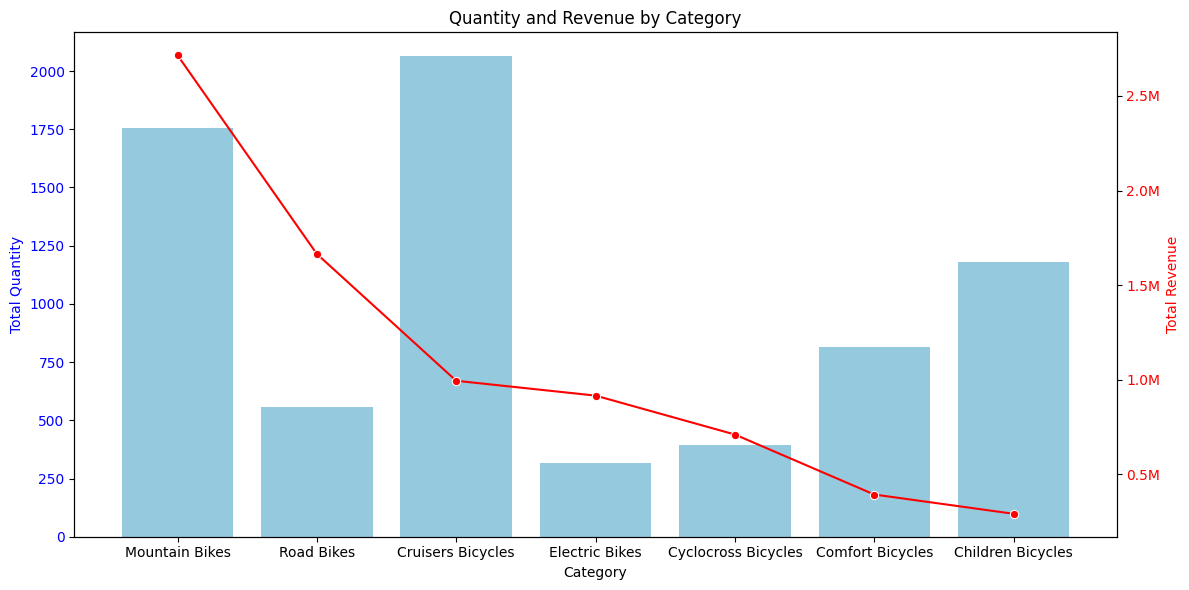

In [13]:
# Plot category quantity and revenue
def millions(x, pos):
    return f'{x*1e-6:.1f}M'

fig, ax1 = plt.subplots(figsize=(12, 6))
sns.barplot(x='category_name', y='quantity', data=category_sales, ax=ax1, color='skyblue')
ax1.set_xlabel('Category')
ax1.set_ylabel('Total Quantity', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax2 = ax1.twinx()
sns.lineplot(x='category_name', y='total_revenue', data=category_sales, ax=ax2, marker='o', color='red')
ax2.set_ylabel('Total Revenue', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.yaxis.set_major_formatter(FuncFormatter(millions))
plt.title('Quantity and Revenue by Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Based on the grouping of product categories by sales volume and total revenue, we can conclude that:

1. Mountain Bikes are the driving force behind bicycle sales in this dataset, leading in terms of revenue (the highest, over $2.5 million) and ranking second in sales volume (approximately 1,750 units).

2. Cruiser Bicycles are the product category with the highest demand (over 2,000 units) but generate relatively moderate revenue (~$1 million). This indicates that products in this category have a unit selling price that is generally budget-friendly.

3. Road Bikes appear to be a premium product category, as evidenced by the high revenue generated (~$1.7 million) despite relatively low demand (~500 units).

4. Children Bicycles have a fairly high demand in the market but contribute the lowest revenue.


Based on the results of this analysis, the following actions can be taken:

1. Capitalize on the strong sales momentum of cruiser bicycles or mountain bikes by creating premium bicycle accessory bundles or offering special deals for upgrades to road bikes.

2. Re-evaluate sales of children’s bicycles, such as by adjusting the profit margin per unit or gradually increasing the selling price per unit

3. Increase the advertising budget allocation for the Mountain Bikes category to maintain market share, and direct product education campaigns toward Road Bikes to attract the high-end target market.



## **Brand Analysis**

In this section, we examine demand from the brand’s perspective and its impact on revenue. The results of the analysis are visualized using a dual-axis bar and line chart.

In [14]:
# Brand_df with quantity and revenue
brand_sales = df_sales.groupby('brand_name').agg({'quantity': 'sum', 'total_revenue': 'sum'}).reset_index()
brand_sales.sort_values('total_revenue', ascending=False, inplace=True)

brand_sales

,brand_name,quantity,total_revenue
8,Trek,1839,"4,602,754.35"
0,Electra,2612,"1,205,320.82"
7,Surly,908,"949,507.06"
6,Sun Bicycles,731,"341,994.93"
1,Haro,331,"185,384.55"
2,Heller,138,"171,459.08"
3,Pure Cycles,376,"149,476.34"
4,Ritchey,118,"78,898.95"
5,Strider,25,"4,320.48"


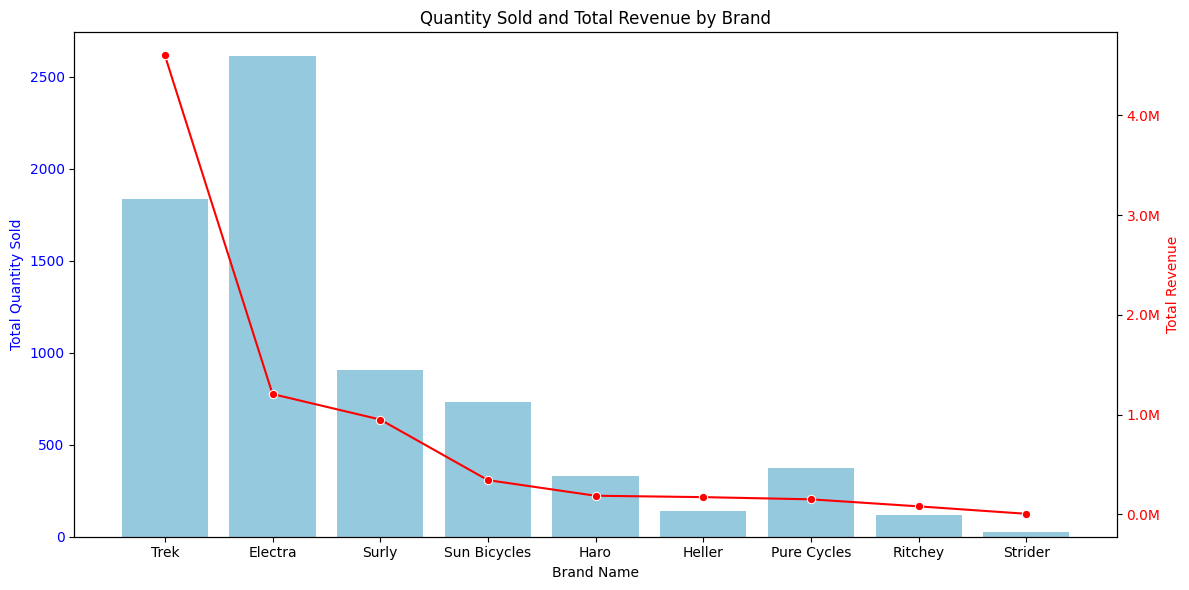

In [15]:
# Plot brands quantity and revenue
def millions(x, pos):
    return f'{x*1e-6:.1f}M'

fig, ax1 = plt.subplots(figsize=(12, 6))
sns.barplot(x='brand_name', y='quantity', data=brand_sales, ax=ax1, color='skyblue')
ax1.set_xlabel('Brand Name')
ax1.set_ylabel('Total Quantity Sold', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax2 = ax1.twinx()
sns.lineplot(x='brand_name', y='total_revenue', data=brand_sales, ax=ax2, color='red', marker='o')
ax2.set_ylabel('Total Revenue', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.yaxis.set_major_formatter(FuncFormatter(millions))
plt.title('Quantity Sold and Total Revenue by Brand')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Based on the brand grouping by total sales and total revenue, we can conclude that:
1. The Trek brand is the largest contributor to the business’s revenue, generating the highest total revenue (exceeding $4.0 million) even though it ranks second in terms of sales volume. This indicates that its unit selling price tends to be high and that it has successfully positioned itself as a sought-after premium product.

2. The Electra brand leads the market in terms of sales volume, recording over 2,500 units sold. However, its revenue contribution is significantly lower than Trek’s (~$1.3 million), indicating that its unit price is more affordable and its sales are oriented toward the mass market.

3. Brands such as Heller, Ritchey, and Strider rank at the bottom in terms of both volume and revenue, indicating a very minimal contribution to overall business growth.

Based on the results of this analysis, the following actions can be taken:
1. Launch a joint marketing campaign. For example, every purchase of a premium Trek bicycle could come with a discount voucher for children’s bicycle brands like Strider, in order to target families.

2. Ensure that safety stock for the Electra brand is always maintained.

3. Conduct an in-depth review of sales for the Heller, Ritchey, and Strider brands, such as re-evaluating the profit margin per unit or considering reducing product variants if maintenance costs for these brands exceed sales revenue.

## **Product Analysis**

In this section, we examine the performance of bicycle products based on demand and their impact on total revenue. The data shows the 10 products with the highest total revenue, visualized using a dual-axis bar and line chart.

In [17]:
# Top 10 Product_df with quantity and revenue
product_sales = df_sales.groupby('product_name').agg({'quantity': 'sum', 'total_revenue': 'sum'}).reset_index()
product_sales.sort_values('total_revenue', ascending=False, inplace=True)
top_products = product_sales.head(10)

top_products


,product_name,quantity,total_revenue
261,Trek Slash 8 27.5 - 2016,154,"555,558.61"
160,Trek Conduit+ - 2016,145,"389,248.70"
212,Trek Fuel EX 8 29 - 2016,143,"368,472.73"
146,Surly Straggler 650b - 2016,151,"226,765.55"
193,Trek Domane SLR 6 Disc - 2017,43,"211,584.62"
144,Surly Straggler - 2016,147,"203,507.62"
254,Trek Remedy 29 Carbon Frameset - 2016,125,"203,380.87"
233,Trek Powerfly 8 FS Plus - 2017,41,"188,249.62"
224,Trek Madone 9.2 - 2017,39,"175,899.65"
260,Trek Silque SLR 8 Women's - 2017,29,"174,524.73"


In [44]:
def thousands(x, pos):
    return f'{x*1e-3:.1f}K'

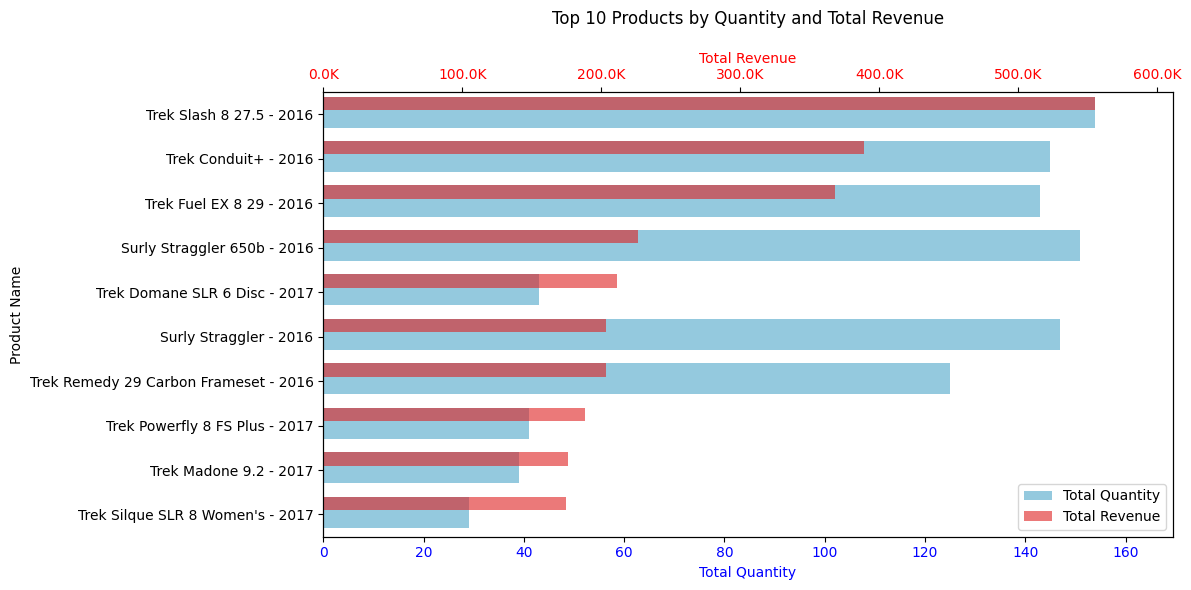

In [47]:
# Plot top 10 brands by quantity and revenue
fig, ax1 = plt.subplots(figsize=(12, 6))

h1 = sns.barplot(x='quantity', y='product_name', data=top_products, ax=ax1, 
            color='skyblue', errorbar=None, height=0.7, label='Total Quantity')
ax1.set_xlabel('Total Quantity', color='blue')
ax1.set_ylabel('Product Name')
ax1.tick_params(axis='x', labelcolor='blue')
ax1.set_xlim(0, top_products['quantity'].max() * 1.1)

ax2 = ax1.twiny()
h2 = sns.barplot(x='total_revenue', y='product_name', data=top_products, ax=ax2, 
            color='red', errorbar=None, alpha=0.6, height=0.3, label='Total Revenue')
ax2.set_xlabel('Total Revenue', color='red')
ax2.tick_params(axis='x', labelcolor='red')
ax2.xaxis.set_major_formatter(FuncFormatter(thousands))
ax2.set_xlim(0, top_products['total_revenue'].max() * 1.1)

# set legend
if ax1.get_legend() is not None:
    ax1.get_legend().remove()
    
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

plt.title('Top 10 Products by Quantity and Total Revenue', pad=20)
plt.tight_layout()
plt.show()

Based on the 10 bicycle products with the highest revenue and demand, we can conclude that:
1. The Trek Slash 8 27.5 - 2016 is the product with the strongest sales performance. This product ranked first in terms of sales volume (>150 units) and generated the highest revenue (over $550K).

2. Products such as the Surly Straggler 650b - 2016, Surly Straggler - 2016, and Trek Remedy 29 Carbon Frameset - 2016 demonstrate very high sales volumes (nearly matching the top-selling product), but their revenue figures are at the lower end. This indicates that these products are very popular in the market but have low selling prices or thin margins.

3. Products like the Trek Domane SLR 6 Disc - 2017 rank 5th in revenue (~$220K) despite relatively low demand (<50 units). This indicates that the product is a premium bicycle with a very high profit margin per unit.

4. The highest-revenue product line is absolutely dominated by the Trek brand (accounting for 8 out of the top 10 products on the list).

Based on the results of this analysis, the following actions can be taken:
1. Always ensure sufficient inventory for products with very high demand, particularly the Trek Slash 8 27.5 - 2016, as it is the main driver of revenue, to avoid running out of stock.

2. The high demand for Surly products can be leveraged as a marketing bridge, such as by offering premium product comparisons with higher margins (e.g., the Trek Domane SLR 6 Disc - 2017).

3. Implement a sales strategy using a pre-order system or displaying products like the Trek Domane SLR 6 Disc - 2017 as the main display units in stores.

## **Top Customer**

In addition to product and brand performance, this analysis highlights the top 10 customers contributing the highest revenue to bicycle sales. By grouping customers based on total purchase volume and total revenue, the insights are visualized using a dual-axis bar and line chart.

In [23]:
# Top Customer_df with quantity and revenue
customer_sales = df_sales.groupby('customer_name').agg({'quantity': 'sum', 'total_revenue': 'sum'}).reset_index()
customer_sales.sort_values('total_revenue', ascending=False, inplace=True)
top_customers = customer_sales.head(10)

top_customers

,customer_name,quantity,total_revenue
1210,Sharyn Hopkins,15,"34,807.94"
1064,Pamelia Newman,18,"33,634.26"
2,Abby Gamble,11,"32,803.01"
892,Lyndsey Bean,16,"32,675.07"
444,Emmitt Sanchez,19,"31,925.89"
958,Melanie Hayes,12,"31,913.69"
338,Debra Burks,17,"27,888.18"
423,Elinore Aguilar,17,"25,636.45"
299,Corrina Sawyer,12,"25,612.70"
1223,Shena Carter,5,"24,890.62"


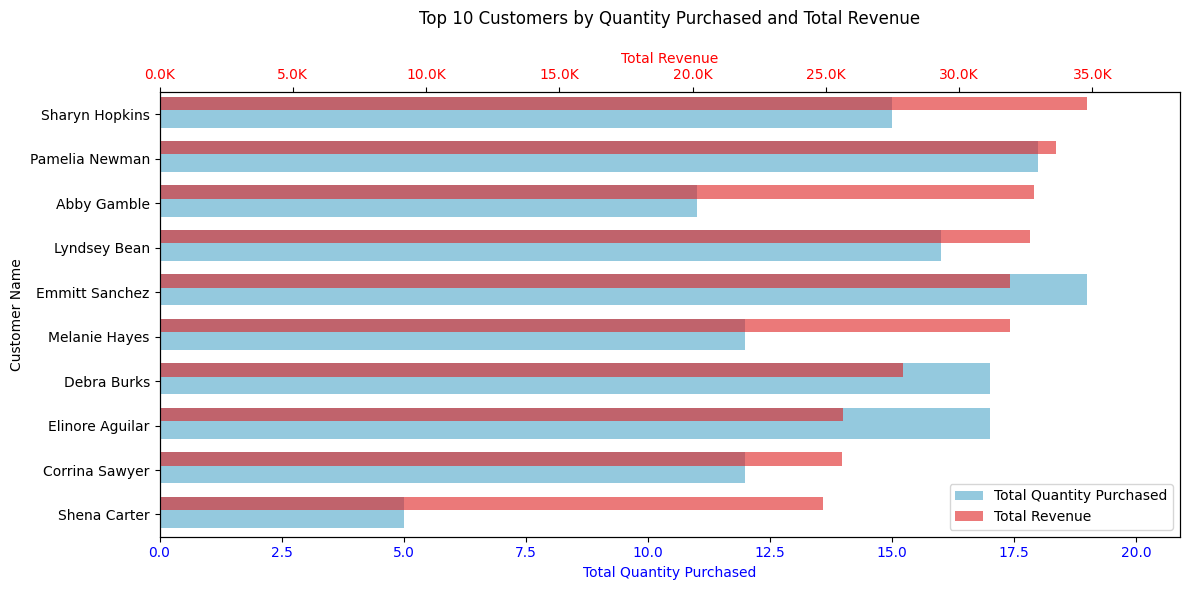

In [49]:
# Plot top 10 customers by quantity and revenue (overlay bar)
fig, ax1 = plt.subplots(figsize=(12, 6))

h1 = sns.barplot(x='quantity', y='customer_name', data=top_customers, ax=ax1, 
            color='skyblue', errorbar=None, height=0.7, label='Total Quantity Purchased')
ax1.set_xlabel('Total Quantity Purchased', color='blue')
ax1.set_ylabel('Customer Name')
ax1.tick_params(axis='x', labelcolor='blue')
ax1.set_xlim(0, top_customers['quantity'].max() * 1.1)

ax2 = ax1.twiny()
h2 = sns.barplot(x='total_revenue', y='customer_name', data=top_customers, ax=ax2, 
            color='red', errorbar=None, alpha=0.6, height=0.3, label='Total Revenue')
ax2.set_xlabel('Total Revenue', color='red')
ax2.tick_params(axis='x', labelcolor='red')
ax2.xaxis.set_major_formatter(FuncFormatter(thousands))
ax2.set_xlim(0, top_customers['total_revenue'].max() * 1.1)

# set legend
if ax1.get_legend() is not None:
    ax1.get_legend().remove()
    
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

plt.title('Top 10 Customers by Quantity Purchased and Total Revenue', pad=20)
plt.tight_layout()
plt.show()


Based on an analysis of the top 10 customers by highest revenue and number of purchases, we can conclude that:
1. The customer named Sharyn Hopkins is the highest revenue contributor in this dataset, with a total purchase value exceeding $34K, although she ranks in the middle in terms of unit quantity.

2. Emmit Sanchez recorded the highest volume of physical purchases (reaching nearly 18 bicycles). However, the total revenue generated ranks fifth (~$32K). This indicates that her purchases are dominated by products with lower unit prices.

3. Abby Gamble demonstrates high-value loyalty. With a relatively moderate purchase volume (~11 units), she managed to rank in the top three in terms of revenue generated (~$33K). This pattern demonstrates her spending orientation focused on premium product lines.

4. Customers like Debra Burks and Elinore Aguilar demonstrate high consistency with a combination of large purchase volumes (>16 units) and moderate revenue contributions.

Based on the analysis results, the following actions can be taken:
1. The company can offer partnership programs or special pricing schemes for resellers (wholesalers) to secure their loyalty and prevent them from switching to competitors.

2. For high-value customers such as Sharyn Hopkins and Abby Gamble, a suitable strategy is to create a loyalty program based on premium services (such as early access to limited-edition products).

3. Send automated offers in the form of periodic maintenance kits or protective accessories to customers who purchase bicycles in large quantities.

## **Store Performanace**

This section highlights the analysis for each store in terms of the number of items sold and their impact on revenue. The results of the analysis are visualized using a dual-axis bar and line chart.

In [25]:
# Demand and revenue by store
store_sales = df_sales.groupby('store_name').agg({'quantity': 'sum', 'total_revenue': 'sum'}).reset_index()
store_sales.sort_values('total_revenue', ascending=False, inplace=True)
store_sales

,store_name,quantity,total_revenue
0,Baldwin Bikes,4779,"5,215,751.28"
2,Santa Cruz Bikes,1516,"1,605,823.04"
1,Rowlett Bikes,783,"867,542.24"


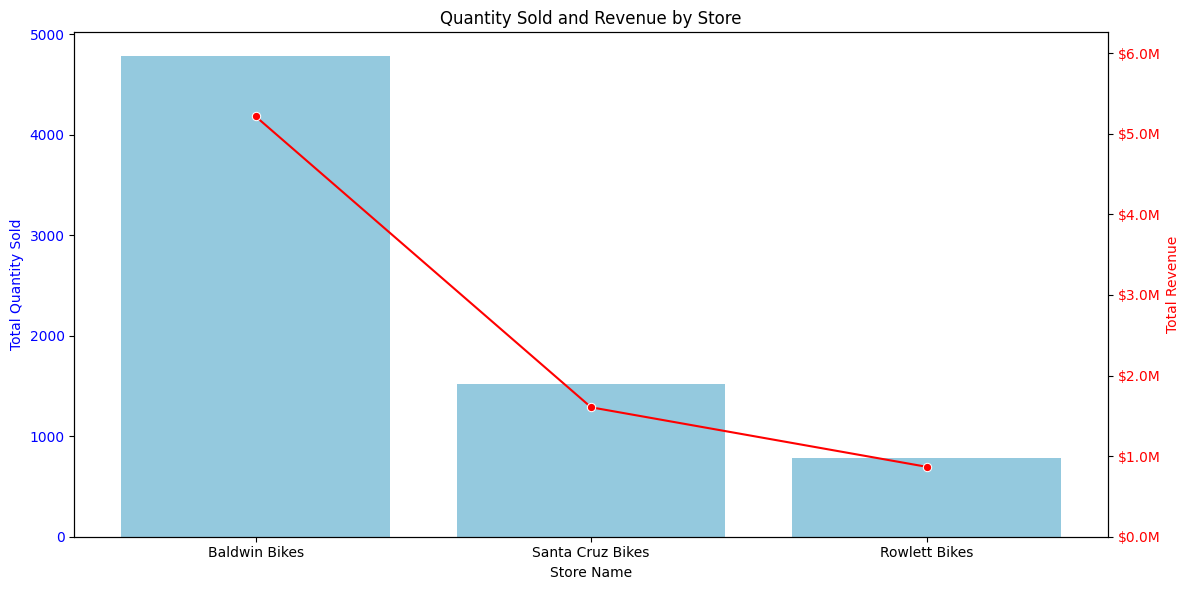

In [50]:
# Plot store quantity and revenue
def millions(x, pos):
    return f'${x*1e-6:.1f}M'

fig, ax1 = plt.subplots(figsize=(12, 6))
sns.barplot(x='store_name', y='quantity', data=store_sales, ax=ax1, color='skyblue')
ax1.set_xlabel('Store Name')
ax1.set_ylabel('Total Quantity Sold', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax2 = ax1.twinx()
sns.lineplot(x='store_name', y='total_revenue', data=store_sales, ax=ax2, marker='o', color='red')
ax2.set_ylabel('Total Revenue', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.yaxis.set_major_formatter(FuncFormatter(millions))
ax2.set_ylim(0, store_sales['total_revenue'].max() * 1.2)
plt.title('Quantity Sold and Revenue by Store')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Based on an analysis of the number of items sold and revenue for each store, we can conclude that:
1. Baldwin Bikes appears to be the main store because it has the highest number of items sold and revenue compared to the other two stores.

2. The Santa Cruz Bikes and Rowlett Bikes stores are identified as branch stores or newer stores because they have lower sales volume and revenue compared to the Baldwin Bikes store.

Based on these analysis results, the following actions can be taken:
1. Prioritize Baldwin Bikes for primary inventory replenishment because this store is the main driver of the company’s cash flow.

2. Evaluate the success factors of Baldwin Bikes (both in terms of management and promotion) to replicate them at the Santa Cruz and Rowlett stores.

3. Run targeted local advertising campaigns specifically for the Santa Cruz and Rowlett areas to increase brand awareness.

# **Inventory Analysis**

In this section, EDA is applied to analyze the product inventory available at each store. In addition, the EDA in this section also covers:
1. Inventory by product category for each store
2. Inventory by product brand for each store

## **Stock per Stores**

In this section, we will analyze the inventory available at each store. The results of this analysis are visualized using bar charts and can be used to inform strategies based on the demand and revenue analysis results for each store, which were previously conducted.

In [51]:
# Stock per store
stock_store = df_inventory.groupby('store_name').agg({'stock_level': 'sum'}).reset_index()
stock_store.sort_values('stock_level', ascending=False, inplace=True)

stock_store

,store_name,stock_level
1,Rowlett Bikes,4620
2,Santa Cruz Bikes,4532
0,Baldwin Bikes,4359


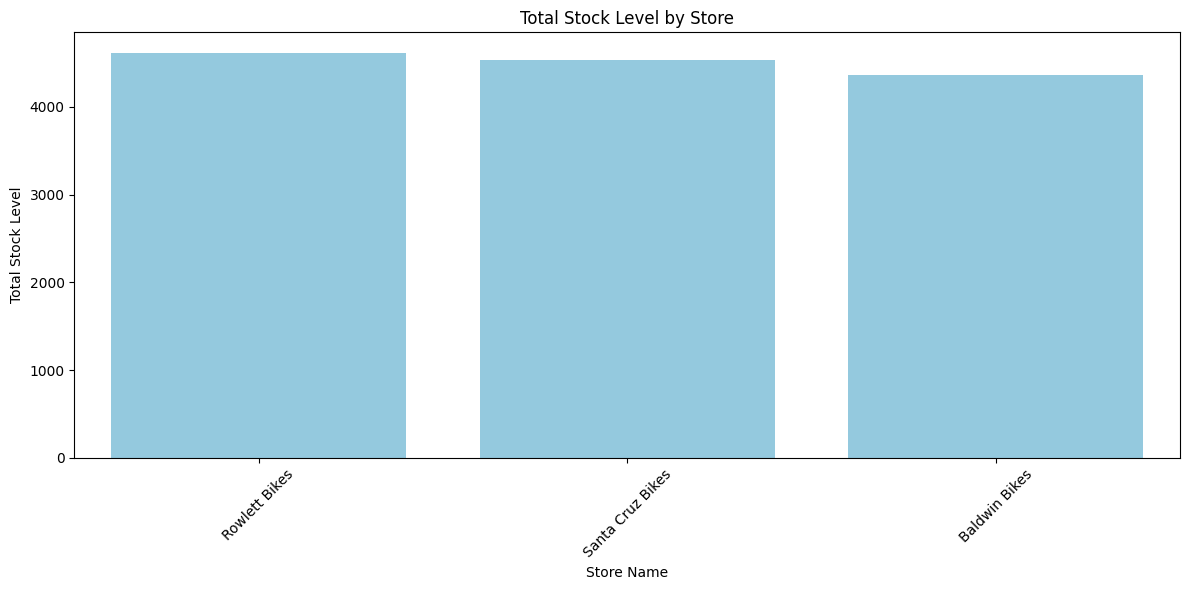

In [52]:
# Plot stock levels per store
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x='store_name', y='stock_level', data=stock_store, ax=ax, color='skyblue')
ax.set_xlabel('Store Name')
ax.set_ylabel('Total Stock Level')
plt.title('Total Stock Level by Store')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Based on the bar chart showing each store’s inventory levels, we can conclude that:
1. An operational management anomaly was identified, in which product inventory was allocated evenly (~4,300–4,600 units per store) without taking into account each branch’s actual sales capacity.

2. Baldwin Bikes, as the main driver of the business (selling >4,700 units), actually has the lowest inventory reserve (4,359 units). This situation is highly prone to triggering lost sales potential due to stockouts.

3. Rowlett Bikes, which has the lowest market performance (historically selling only 783 units), actually holds the highest physical inventory at 4,620 units. This indicates working capital inefficiency tied up in slow-moving inventory.

Based on the results of this analysis, the following actions can be taken:
1. Transfer a portion of the fast-moving product inventory from the Rowlett Bikes and Santa Cruz Bikes warehouses directly to the Baldwin Bikes warehouse.

2. Change the restocking policy from a Push system (where the headquarters distributes goods evenly to all stores) to a Pull system (where stores request goods based on their historical sales forecasts).

## **Stock Distribution by Category**

In this section, we analyze the net remaining stock for each product category as well as the stock levels for each category in each store. The net remaining stock is calculated by subtracting the demand (quantity) from the stock level. The results of the analysis are visualized using a bar chart for net remaining stock and a heatmap for stock by category in each store.

In [58]:
# Stock per category
stock_category = df_inventory.groupby('category_name').agg({'stock_level': 'sum'}).reset_index()

# Demand per category
category_demand = df_sales.groupby('category_name').agg({'quantity': 'sum'}).reset_index()

# Merge and count stock minus demand
stock_demand_category = pd.merge(stock_category, category_demand, on='category_name', how='left')
stock_demand_category['stock_minus_demand'] = stock_demand_category['stock_level'] - stock_demand_category['quantity']
stock_demand_category.sort_values('stock_minus_demand', ascending=False, inplace=True)

stock_demand_category

,category_name,stock_level,quantity,stock_minus_demand
6,Road Bikes,2091,559,1532
0,Children Bicycles,2608,1179,1429
2,Cruisers Bicycles,3378,2063,1315
5,Mountain Bikes,2654,1755,899
4,Electric Bikes,1108,315,793
1,Comfort Bicycles,1258,813,445
3,Cyclocross Bicycles,414,394,20


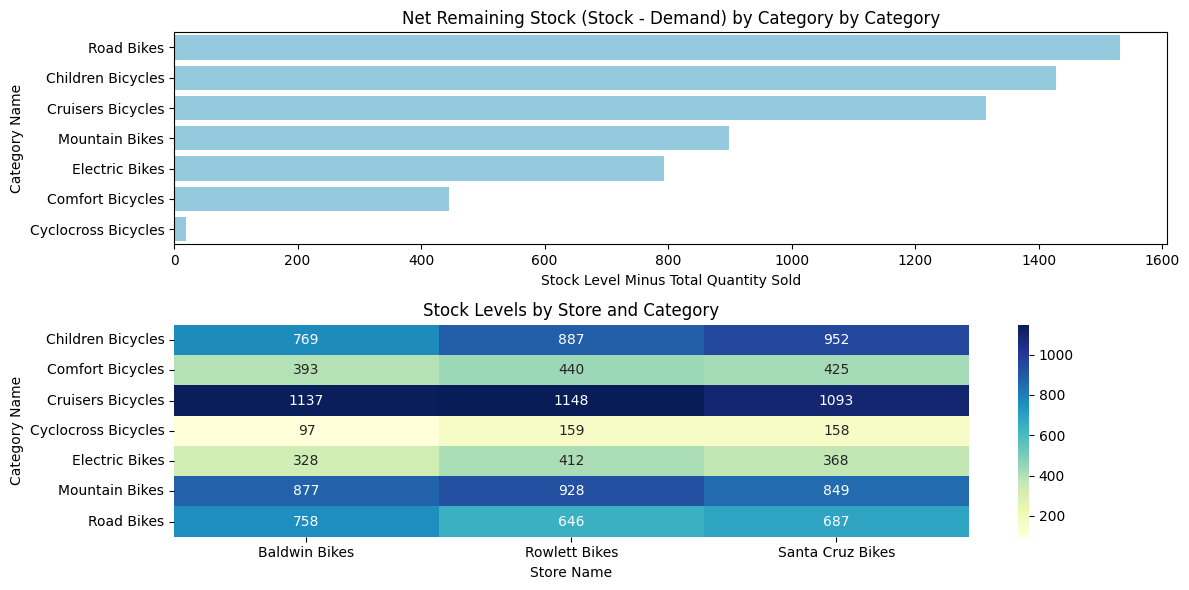

In [71]:
# Plot of stock minus demand per category and heatmap of stock distribution across stores and categories
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

# Bar plot of stock minus demand per category
sns.barplot(x='stock_minus_demand', y='category_name', data=stock_demand_category, ax=ax1, color='skyblue', errorbar=None)
ax1.set_title('Net Remaining Stock (Stock - Demand) by Category by Category')
ax1.set_xlabel('Stock Level Minus Total Quantity Sold')
ax1.set_ylabel('Category Name')

# Heatmap of stock distribution across stores and categories
stock_pivot = df_inventory.pivot_table(index='category_name', columns='store_name', values='stock_level', aggfunc='sum', fill_value=0)
sns.heatmap(stock_pivot, annot=True, fmt='d', cmap='YlGnBu', ax=ax2)
ax2.set_title('Stock Levels by Store and Category')
ax2.set_xlabel('Store Name')
ax2.set_ylabel('Category Name')
plt.tight_layout()
plt.show()

Based on these two charts, the following conclusions can be drawn:
1. The Road Bikes category has the highest inventory surplus (>1,500 units), with 2,091 units in stock compared to a demand of 559 units. Given that this category consists of high-value premium products, the accumulation of unsold inventory has the potential to increase holding costs and slow down working capital turnover.

2. The Cruisers and Children’s Bicycles categories show high inventory surpluses (over 1,300 units and over 1,400 units, respectively) despite relatively strong demand. Based on the heatmap, this indicates a distribution pattern that is too uniform across branches (approximately 1,000 units and 700–900 units per branch, respectively) without accounting for demand variations by store.

3. The Cyclocross Bicycles category has the lowest stock buffer (surplus <50 units), making it at risk of stockouts, particularly at Baldwin Bikes, the branch with the highest demand.

Based on the analysis results, the following steps can be taken:
1. Redistribute stock from categories with high surpluses (Cruisers, Children’s Bicycles, and Road Bikes) from branches with excess inventory to Baldwin Bikes to improve inventory turnover and reduce the risk of stockouts.

2. Implement promotions or bundling for the Road Bikes category to accelerate the movement of slower-moving premium stock.

3. Review replenishment for categories with high surplus, particularly Road Bikes and Electric Bikes, until inventory levels are better aligned with actual demand.

4. Change the inventory allocation strategy from uniform distribution to demand-based allocation based on historical sales per store.

## **Stock Distribution by Brand**

In addition to product categories, an analysis of remaining stock was also conducted for each brand in each store. This analysis included calculating the net remaining stock (stock level - demand) for each brand and calculating the total product stock by brand in each store. The results of the analysis were visualized using bar charts for net remaining stock and heatmaps for stock levels by brand in each store.

In [72]:
# Total stock by brands
stock_brand = df_inventory.groupby('brand_name').agg({'stock_level': 'sum'}).reset_index()

# Total demand by brands
demand_brand = df_sales.groupby('brand_name').agg({'quantity': 'sum'}).reset_index()

# Merge and count stock minus demand
stock_demand_brand = pd.merge(stock_brand, demand_brand, on='brand_name', how='left')
stock_demand_brand['stock_minus_demand'] = stock_demand_brand['stock_level'] - stock_demand_brand['quantity']
stock_demand_brand.sort_values('stock_minus_demand', ascending=False, inplace=True)

stock_demand_brand

,brand_name,stock_level,quantity,stock_minus_demand
8,Trek,5519,1839,3680
0,Electra,4998,2612,2386
6,Sun Bicycles,1042,731,311
7,Surly,1105,908,197
1,Haro,454,331,123
5,Strider,136,25,111
2,Heller,108,138,-30
4,Ritchey,45,118,-73
3,Pure Cycles,104,376,-272


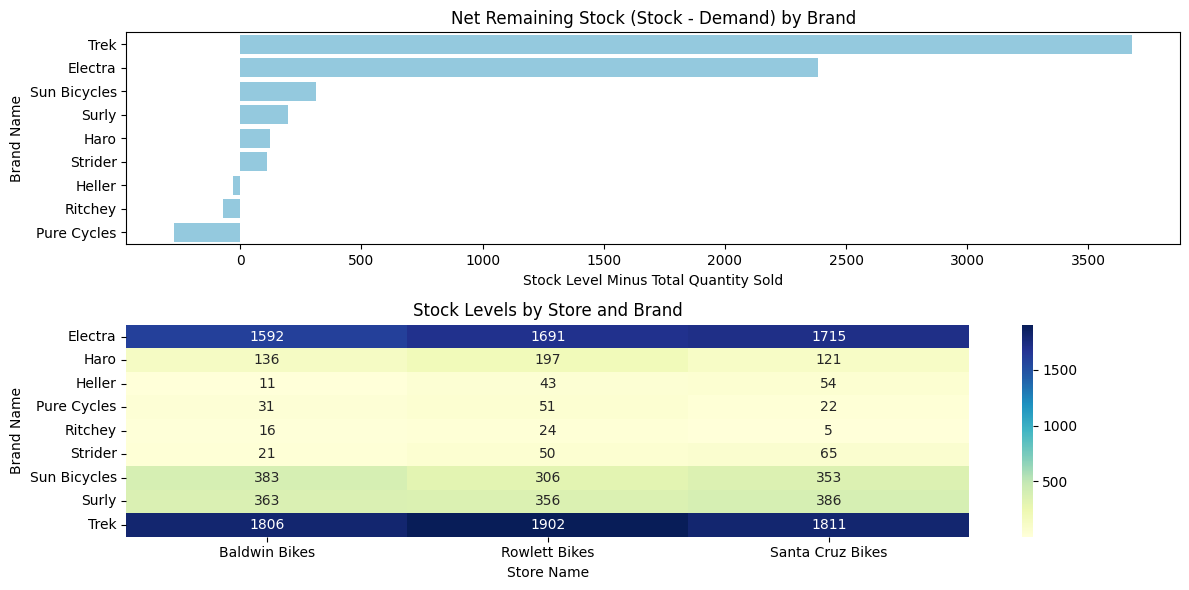

In [76]:
# Plot of stock minus demand per brands and heatmap of stock distribution across stores and brands
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

# Bar plot of stock minus demand per brand
sns.barplot(x='stock_minus_demand', y='brand_name', data=stock_demand_brand, ax=ax1, color='skyblue', errorbar=None)
ax1.set_title('Net Remaining Stock (Stock - Demand) by Brand')
ax1.set_xlabel('Stock Level Minus Total Quantity Sold')
ax1.set_ylabel('Brand Name')

# Heatmap of stock levels by brand and store
stock_brand_pivot = df_inventory.pivot_table(index='brand_name', columns='store_name', values='stock_level', aggfunc='sum').fillna(0)
sns.heatmap(stock_brand_pivot, annot=True, fmt='g', cmap='YlGnBu', ax=ax2)
ax2.set_title('Stock Levels by Store and Brand')
ax2.set_xlabel('Store Name')
ax2.set_ylabel('Brand Name')
plt.tight_layout()
plt.show()

Based on these two charts, we can conclude that:
1. Trek and Electra have the highest inventory surpluses, at 3,680 units and 2,386 units, respectively. As the two brands with the largest revenue contributions, these high levels of unsold inventory indicate a potential for overstocking, which could increase storage costs and reduce working capital efficiency.

2. The heatmap shows that Trek and Electra have relatively uniform inventory distribution across all branches, at approximately 1,800 and 1,600 units per store, respectively. However, this homogeneous distribution approach is suboptimal because it does not account for differences in demand at each store and risks causing stock shortages, particularly at Baldwin Bikes.

3. There are three brands experiencing a supply deficit (demand exceeds inventory): Heller, Ritchey, and Pure Cycles. Although the demand volume for these three brands is relatively low, limited inventory still has the potential to result in lost sales opportunities in more specific market segments.

Based on the analysis results, the following actions can be taken:
1. Redistribute Trek and Electra brand inventory from branches with high surpluses (Rowlett Bikes and Santa Cruz Bikes) to Baldwin Bikes, which has the highest demand and revenue, to improve inventory turnover efficiency.

2. Optimize promotional or bundling strategies for the Trek and Electra brands at branches with excess inventory to accelerate inventory turnover.

3. Review the replenishment policy and postpone additional purchases for the Trek and Electra brands until inventory levels return to a point closer to actual demand.

4. Conduct limited procurement for the Heller, Ritchey, and Pure Cycles brands to address unmet market demand.

# **Staff Performance Analysis**

In this section, we analyze the performance of staff at each store in terms of the number of orders they handle. The results of the analysis are visualized using a bar chart.

,staff_id,staff_name,store_name,manager_id,total_orders_handled
0,1,Fabiola Jackson,Santa Cruz Bikes,NaN,0
1,2,Mireya Copeland,Santa Cruz Bikes,1.00,164
2,3,Genna Serrano,Santa Cruz Bikes,2.00,184
3,4,Virgie Wiggins,Santa Cruz Bikes,2.00,0
4,5,Jannette David,Baldwin Bikes,1.00,0
5,6,Marcelene Boyer,Baldwin Bikes,5.00,553
6,7,Venita Daniel,Baldwin Bikes,5.00,540
7,8,Kali Vargas,Rowlett Bikes,1.00,88
8,9,Layla Terrell,Rowlett Bikes,7.00,86
9,10,Bernardine Houston,Rowlett Bikes,7.00,0


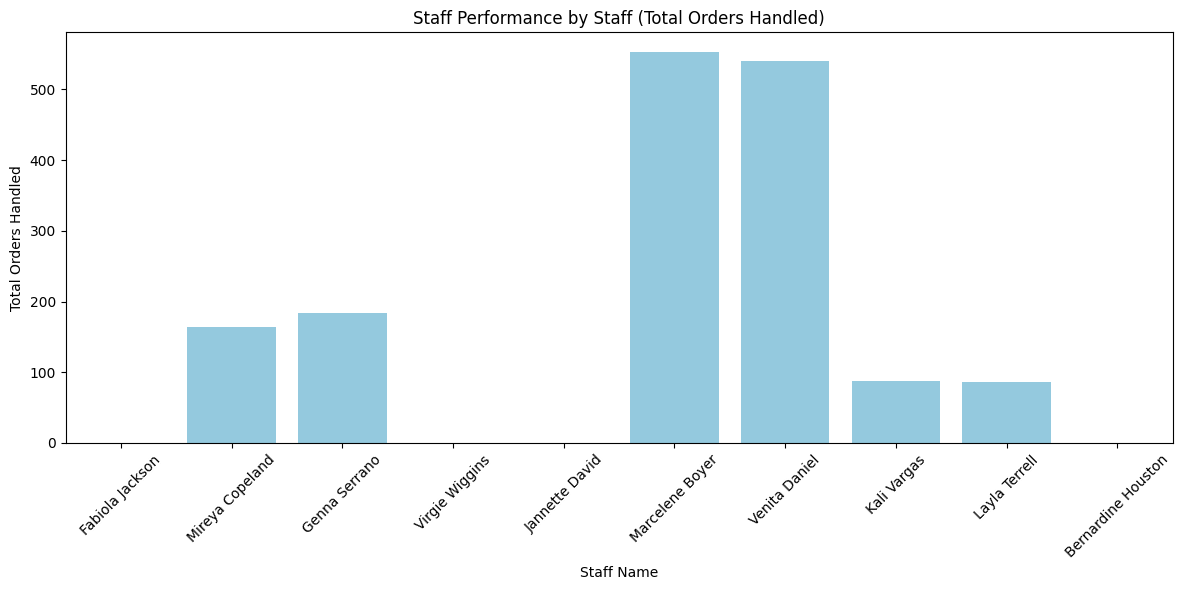

In [77]:
# Staff performance analysis

display(df_staff_performance)

plt.figure(figsize=(12, 6))
sns.barplot(x='staff_name', y='total_orders_handled', data=df_staff_performance, color='skyblue')
plt.xlabel('Staff Name')
plt.ylabel('Total Orders Handled')
plt.title('Staff Performance by Staff (Total Orders Handled)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Based on the staff performance data and the generated plot, we can conclude that:
1. **The management hierarchy is relatively consistent at the top level**, where Fabiola Jackson (`staff_id = 1`) is identified as the highest-ranking manager because she does not have a `manager_id`, while Mireya Copeland (`staff_id = 2`), Jannette David (`staff_id = 5`), and Kali Vargas (`staff_id = 8`) are assumed to be the managers of their respective branches since they all report to Fabiola.

2. **Managerial roles across branches are inconsistent**. Mireya Copeland and Kali Vargas continue to handle orders (164 and 88 orders, respectively), while Jannette David handles no orders at all despite being assigned to Baldwin Bikes, the branch with the highest demand and revenue.

3. **Active staff members with no order contributions were identified**, such as Virgie Wiggins (`staff_id = 4`) and Bernardine Houston (`staff_id = 10`), who are active but have recorded 0 orders. A similar situation occurs with Jannette David, suggesting the possibility of administrative staff, new hires, or incomplete transactional logging.

4. **There is an anomaly in the Rowlett Bikes reporting structure**, where Layla Terrel (`staff_id=9`) and Bernadine Houston (`staff_id=10`) are listed as reporting to Venita Daniel (`staff_id = 7`) at Baldwin Bikes, rather than to Kali Vargas, who is assumed to be the manager of Rowlett. This indicates a possible foreign key error or inconsistency in the organizational structure records.

Based on the findings of the analysis, the following actions can be taken:
1. Audit the staff reporting structure by re-verifying the `manager_id` relationships, particularly at Rowlett Bikes, to ensure that each staff member is linked to the appropriate supervisor based on branch and role.

2. Review staff activity status by comparing active status attributes against actual transaction data to identify potential non-operational staff, new hires, or status recording errors.

3. Standardize the definitions of roles and responsibilities between managers and sales staff, as the data shows inconsistencies in manager participation in sales activities across branches.

4. Recognize staff who handle a high volume of orders or managers who assist in order processing.